<a href="https://colab.research.google.com/github/aqib-ali-29184/pdc-feature-selection/blob/milestone-2/milestone2_parallel_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import threading
import time
import warnings
import os
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


In [26]:
# ============================================================
# MILESTONE 1 BUILDING BLOCKS
# ============================================================

class DatasetLoader:
    def __init__(self, dataset_name: str):
        self.dataset_name = dataset_name
        self.X = None
        self.y = None

    def load(self):
        print(f"\n📦 Loading dataset: {self.dataset_name} ...")
        if self.dataset_name == "mnist":
            from keras.datasets import mnist
            (X_train, y_train), (X_test, y_test) = mnist.load_data()
            X_all = np.concatenate([X_train, X_test], axis=0)
            y_all = np.concatenate([y_train, y_test], axis=0)
            self.X = X_all.reshape(X_all.shape[0], -1).astype(np.float32)
            self.y = y_all.astype(int)
        elif self.dataset_name == "cifar10_gray":
            from keras.datasets import cifar10
            import cv2
            (X_train, y_train), (X_test, y_test) = cifar10.load_data()
            X_all = np.concatenate([X_train, X_test], axis=0)
            y_all = np.concatenate([y_train.flatten(), y_test.flatten()], axis=0)
            self.X = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).flatten()
                                for img in X_all], dtype=np.float32)
            self.y = y_all
        elif self.dataset_name == "madelon":
            X, y = make_classification(n_samples=2600, n_features=500,
                                        n_informative=20, n_redundant=480,
                                        n_classes=2, random_state=42)
            self.X = X.astype(np.float32)
            self.y = y.astype(int)
        else:
            raise ValueError(f"Unknown dataset: {self.dataset_name}")
        print(f"   Shape: {self.X.shape} | Classes: {np.unique(self.y)}")
        return self

    def preprocess(self, sample_size=None):
        if sample_size and sample_size < len(self.X):
            np.random.seed(42)
            idx = np.random.choice(len(self.X), sample_size, replace=False)
            self.X = self.X[idx]
            self.y = self.y[idx]
            print(f"   Subsampled to {sample_size} samples")
        scaler = MinMaxScaler()
        self.X = scaler.fit_transform(self.X)
        print(f"   ✅ Preprocessing done.")
        return self

    def split(self, test_size=0.2, random_state=42):
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=test_size,
            random_state=random_state, stratify=self.y)
        print(f"   Train: {X_train.shape}, Test: {X_test.shape}")
        return X_train, X_test, y_train, y_test


class NaiveBayesEvaluator:
    def __init__(self):
        pass  # no shared model — keeps threads safe

    def evaluate(self, X_train, X_test, y_train, y_test, feature_mask=None):
        if feature_mask is not None:
            selected = np.where(np.array(feature_mask) == 1)[0]
            if len(selected) == 0:
                return 0.0, 0.0
            X_tr = X_train[:, selected]
            X_te = X_test[:, selected]
        else:
            X_tr, X_te = X_train, X_test
        start = time.time()
        model = GaussianNB()          # fresh instance every call — thread-safe
        model.fit(X_tr, y_train)
        preds = model.predict(X_te)
        elapsed = time.time() - start
        return accuracy_score(y_test, preds), elapsed


class BinaryMaskEncoder:
    def __init__(self, n_features):
        self.n_features = n_features
    def all_ones(self):
        return np.ones(self.n_features, dtype=int)
    def random_mask(self, density=0.5, seed=None):
        if seed is not None:
            np.random.seed(seed)
        return (np.random.rand(self.n_features) < density).astype(int)
    def mask_to_string(self, mask):
        return ''.join(map(str, mask))


class FitnessFunction:
    def __init__(self, evaluator, alpha=0.01):
        self.evaluator = evaluator
        self.alpha = alpha

    def evaluate(self, mask, X_train, X_test, y_train, y_test):
        mask = np.array(mask)
        n_total    = len(mask)
        n_selected = int(np.sum(mask))
        if n_selected == 0:
            return 0.0, 0.0, 0, 0.0
        accuracy, time_taken = self.evaluator.evaluate(
            X_train, X_test, y_train, y_test, feature_mask=mask)
        score = accuracy - (self.alpha * n_selected / n_total)
        return score, accuracy, n_selected, time_taken


class ResultsLogger:
    def __init__(self, dataset_name):
        self.dataset_name = dataset_name
        self.records = []

    def log(self, mask, score, accuracy, n_selected, time_taken, label=""):
        encoder = BinaryMaskEncoder(len(mask))
        self.records.append({
            "dataset": self.dataset_name, "label": label,
            "score": round(score, 6), "accuracy": round(accuracy, 6),
            "n_selected": n_selected, "n_total": len(mask),
            "feature_%": round(100 * n_selected / len(mask), 2),
            "time_s": round(time_taken, 6),
            "mask_str": encoder.mask_to_string(mask)
        })

    def get_best(self):
        if not self.records:
            return None
        return max(self.records, key=lambda r: r["score"])

    def to_dataframe(self):
        return pd.DataFrame(self.records)

    def save_csv(self, filename=None):
        if filename is None:
            filename = f"fitness_results_{self.dataset_name}.csv"
        df = self.to_dataframe()
        df.to_csv(filename, index=False)
        print(f"✅ Saved {len(df)} results to '{filename}'")
        return filename

    def print_summary(self):
        df = self.to_dataframe()
        if df.empty:
            print("No results logged yet.")
            return
        print(f"\n📋 RESULTS SUMMARY — {self.dataset_name.upper()}")
        print(f"   Total evaluations : {len(df)}")
        print(f"   Best accuracy     : {df['accuracy'].max()*100:.2f}%")
        print(f"   Best score        : {df['score'].max():.6f}")
        print(f"   Avg features used : {df['n_selected'].mean():.1f} / {df['n_total'].iloc[0]}")
        top5 = df.nlargest(5, 'score')[['label','accuracy','n_selected','feature_%','score']]
        print(f"\n   Top 5 results:\n{top5.to_string(index=False)}")

print("✅ All Milestone 1 classes loaded.")

✅ All Milestone 1 classes loaded.


In [27]:
# ============================================================
# MILESTONE 2 — ADDITION OPERATOR
# ============================================================

class FeatureBiasComputer:
    def __init__(self, bias_temperature=2.0, random_state=42):
        self.bias_temperature = bias_temperature
        self.random_state     = random_state
        self.ig_scores_       = None
        self.probabilities_   = None

    def fit(self, X_train, y_train):
        print("   ⏳ Computing IG scores ...", end=" ")
        start = time.time()
        ig = mutual_info_classif(X_train, y_train,
                                  discrete_features=False,
                                  random_state=self.random_state)
        self.ig_scores_ = ig
        shifted  = ig - ig.max()
        exp_vals = np.exp(self.bias_temperature * shifted)
        self.probabilities_ = exp_vals / exp_vals.sum()
        print(f"done ({time.time()-start:.1f}s) | "
              f"IG range: [{ig.min():.4f}, {ig.max():.4f}]")
        return self

    def get_addition_probabilities(self, mask):
        probs = self.probabilities_.copy()
        probs[mask == 1] = 0.0
        total = probs.sum()
        if total == 0:
            probs = np.ones(len(mask)) / len(mask)
        else:
            probs /= total
        return probs


class AdditionOperator:
    def __init__(self, fitness_fn, bias_computer,
                 n_additions=3, use_bias=True, random_state=42):
        self.fitness_fn    = fitness_fn
        self.bias_computer = bias_computer
        self.n_additions   = n_additions
        self.use_bias      = use_bias
        self._rng          = np.random.default_rng(random_state)

    def _pick_features_to_add(self, mask):
        inactive = np.where(mask == 0)[0]
        if len(inactive) == 0:
            return np.array([], dtype=int)
        n_to_add = min(self.n_additions, len(inactive))
        if self.use_bias:
            probs = self.bias_computer.get_addition_probabilities(mask)
            inactive_probs = probs[inactive]
            s = inactive_probs.sum()
            inactive_probs = inactive_probs / s if s > 0 else np.ones(len(inactive)) / len(inactive)
            chosen = self._rng.choice(inactive, size=n_to_add, replace=False, p=inactive_probs)
        else:
            chosen = self._rng.choice(inactive, size=n_to_add, replace=False)
        return chosen

    def _add_features(self, mask, indices):
        new_mask = mask.copy()
        for idx in indices:
            if new_mask[idx] == 0:
                new_mask[idx] = 1
        return new_mask

    def operate(self, population, X_train, X_test, y_train, y_test,
                logger=None, generation=0):
        new_population = []
        n_improved     = 0
        all_scores     = []

        for i, mask in enumerate(population):
            mask = np.array(mask, dtype=int)
            curr_score, curr_acc, curr_n, curr_t = self.fitness_fn.evaluate(
                mask, X_train, X_test, y_train, y_test)
            to_add    = self._pick_features_to_add(mask)
            candidate = self._add_features(mask, to_add)

            if len(to_add) == 0:
                new_population.append(mask)
                all_scores.append(curr_score)
                if logger:
                    logger.log(mask, curr_score, curr_acc, curr_n, curr_t,
                               label=f"add_gen{generation}_mask{i}_no_inactive")
                continue

            cand_score, cand_acc, cand_n, cand_t = self.fitness_fn.evaluate(
                candidate, X_train, X_test, y_train, y_test)

            if cand_score > curr_score:
                accepted, accepted_score, n_improved = candidate, cand_score, n_improved + 1
                label = f"add_gen{generation}_mask{i}_improved"
            else:
                accepted, accepted_score = mask, curr_score
                label = f"add_gen{generation}_mask{i}_kept"

            new_population.append(accepted)
            all_scores.append(accepted_score)
            if logger:
                logger.log(candidate, cand_score, cand_acc, cand_n, cand_t, label=label)

        stats = {
            "generation": generation, "population_size": len(population),
            "n_improved": n_improved,
            "improvement_rate": n_improved / max(len(population), 1),
            "avg_score": float(np.mean(all_scores)) if all_scores else 0.0,
            "best_score": float(np.max(all_scores)) if all_scores else 0.0,
        }
        return new_population, stats

print("✅ FeatureBiasComputer + AdditionOperator loaded.")

✅ FeatureBiasComputer + AdditionOperator loaded.


In [28]:
# ============================================================
# MILESTONE 2 — REMOVAL OPERATOR
# ============================================================

class SparsityBiasComputer:
    def __init__(self, bias_temperature=2.0, random_state=42):
        self.bias_temperature = bias_temperature
        self.random_state     = random_state
        self.ig_scores_       = None
        self.removal_probs_   = None

    def fit(self, X_train, y_train):
        print("   ⏳ Computing sparsity bias ...", end=" ")
        start = time.time()
        ig = mutual_info_classif(X_train, y_train,
                                  discrete_features=False,
                                  random_state=self.random_state)
        self.ig_scores_ = ig
        inverted = ig.max() - ig
        shifted  = inverted - inverted.max()
        exp_vals = np.exp(self.bias_temperature * shifted)
        self.removal_probs_ = exp_vals / exp_vals.sum()
        print(f"done ({time.time()-start:.1f}s)")
        return self

    def get_removal_probabilities(self, mask):
        probs = self.removal_probs_.copy()
        probs[mask == 0] = 0.0
        total = probs.sum()
        if total == 0:
            probs = np.ones(len(mask)) / len(mask)
        else:
            probs /= total
        return probs


class RemovalOperator:
    def __init__(self, fitness_fn, sparsity_computer,
                 n_removals=3, use_bias=True, min_features=5, random_state=42):
        self.fitness_fn        = fitness_fn
        self.sparsity_computer = sparsity_computer
        self.n_removals        = n_removals
        self.use_bias          = use_bias
        self.min_features      = min_features
        self._rng              = np.random.default_rng(random_state)

    def _pick_features_to_remove(self, mask):
        active = np.where(mask == 1)[0]
        max_removable = len(active) - self.min_features
        if max_removable <= 0:
            return np.array([], dtype=int)
        n_to_remove = min(self.n_removals, max_removable)
        if self.use_bias:
            probs = self.sparsity_computer.get_removal_probabilities(mask)
            active_probs = probs[active]
            s = active_probs.sum()
            active_probs = active_probs / s if s > 0 else np.ones(len(active)) / len(active)
            chosen = self._rng.choice(active, size=n_to_remove, replace=False, p=active_probs)
        else:
            chosen = self._rng.choice(active, size=n_to_remove, replace=False)
        return chosen

    def _remove_features(self, mask, indices):
        new_mask = mask.copy()
        for idx in indices:
            if new_mask[idx] == 1:
                new_mask[idx] = 0
        return new_mask

    def operate(self, population, X_train, X_test, y_train, y_test,
                logger=None, generation=0):
        new_population = []
        n_improved     = 0
        all_scores     = []

        for i, mask in enumerate(population):
            mask = np.array(mask, dtype=int)
            curr_score, curr_acc, curr_n, curr_t = self.fitness_fn.evaluate(
                mask, X_train, X_test, y_train, y_test)
            to_remove = self._pick_features_to_remove(mask)
            candidate = self._remove_features(mask, to_remove)

            if len(to_remove) == 0:
                new_population.append(mask)
                all_scores.append(curr_score)
                if logger:
                    logger.log(mask, curr_score, curr_acc, curr_n, curr_t,
                               label=f"rem_gen{generation}_mask{i}_at_minimum")
                continue

            cand_score, cand_acc, cand_n, cand_t = self.fitness_fn.evaluate(
                candidate, X_train, X_test, y_train, y_test)

            if cand_score > curr_score:
                accepted, accepted_score, n_improved = candidate, cand_score, n_improved + 1
                label = f"rem_gen{generation}_mask{i}_improved"
            else:
                accepted, accepted_score = mask, curr_score
                label = f"rem_gen{generation}_mask{i}_kept"

            new_population.append(accepted)
            all_scores.append(accepted_score)
            if logger:
                logger.log(candidate, cand_score, cand_acc, cand_n, cand_t, label=label)

        stats = {
            "generation": generation, "population_size": len(population),
            "n_improved": n_improved,
            "improvement_rate": n_improved / max(len(population), 1),
            "avg_score": float(np.mean(all_scores)) if all_scores else 0.0,
            "best_score": float(np.max(all_scores)) if all_scores else 0.0,
        }
        return new_population, stats

print("✅ SparsityBiasComputer + RemovalOperator loaded.")

✅ SparsityBiasComputer + RemovalOperator loaded.


In [29]:
# ============================================================
# POPULATION FACTORY
# ============================================================

def create_initial_population(n_features, population_size=20,
                               init_density=0.3, bias_computer=None,
                               top_k_seed=5, random_state=42):
    rng        = np.random.default_rng(random_state)
    population = []

    if bias_computer is not None and bias_computer.ig_scores_ is not None:
        n_warm = min(top_k_seed, population_size)
        for k in range(1, n_warm + 1):
            mask = np.zeros(n_features, dtype=int)
            top_indices = np.argsort(bias_computer.ig_scores_)[::-1][
                          :k * max(1, n_features // 20)]
            mask[top_indices] = 1
            population.append(mask)
    else:
        n_warm = 0

    n_random = population_size - len(population)
    for _ in range(n_random):
        mask = (rng.random(n_features) < init_density).astype(int)
        if mask.sum() == 0:
            mask[rng.integers(n_features)] = 1
        population.append(mask)

    print(f"✅ Population: {len(population)} masks "
          f"({n_warm} IG-seeded + {n_random} random, density≈{init_density:.0%})")
    return population

print("✅ create_initial_population() loaded.")

✅ create_initial_population() loaded.


In [30]:
# ============================================================
# LOAD DATASETS + FIT BIAS COMPUTERS
# ============================================================

datasets = {}
for ds_name, sample_size in [("mnist", 5000), ("madelon", None), ("cifar10_gray", 5000)]:
    loader = DatasetLoader(ds_name)
    loader.load().preprocess(sample_size=sample_size)
    X_train, X_test, y_train, y_test = loader.split()
    datasets[ds_name] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "n_features": X_train.shape[1]
    }

print("\n✅ All datasets loaded.\n")

bias_computers     = {}
sparsity_computers = {}

for ds_name, data in datasets.items():
    print(f"🔍 {ds_name.upper()}")
    bc = FeatureBiasComputer(bias_temperature=2.0, random_state=42)
    bc.fit(data["X_train"], data["y_train"])
    bias_computers[ds_name] = bc

    sc = SparsityBiasComputer(bias_temperature=2.0, random_state=42)
    sc.fit(data["X_train"], data["y_train"])
    sparsity_computers[ds_name] = sc

print("\n✅ Both bias computers fitted for all datasets.")


📦 Loading dataset: mnist ...
   Shape: (70000, 784) | Classes: [0 1 2 3 4 5 6 7 8 9]
   Subsampled to 5000 samples
   ✅ Preprocessing done.
   Train: (4000, 784), Test: (1000, 784)

📦 Loading dataset: madelon ...
   Shape: (2600, 500) | Classes: [0 1]
   ✅ Preprocessing done.
   Train: (2080, 500), Test: (520, 500)

📦 Loading dataset: cifar10_gray ...
   Shape: (60000, 1024) | Classes: [0 1 2 3 4 5 6 7 8 9]
   Subsampled to 5000 samples
   ✅ Preprocessing done.
   Train: (4000, 1024), Test: (1000, 1024)

✅ All datasets loaded.

🔍 MNIST
   ⏳ Computing IG scores ... done (21.1s) | IG range: [0.0000, 0.2991]
   ⏳ Computing sparsity bias ... done (21.8s)
🔍 MADELON
   ⏳ Computing IG scores ... done (4.7s) | IG range: [0.0000, 0.1293]
   ⏳ Computing sparsity bias ... done (5.6s)
🔍 CIFAR10_GRAY
   ⏳ Computing IG scores ... done (28.4s) | IG range: [0.0000, 0.0935]
   ⏳ Computing sparsity bias ... done (28.9s)

✅ Both bias computers fitted for all datasets.


In [31]:
# ============================================================
# CELL 7 — MERGE POPULATIONS
# ============================================================

def merge_populations(pop_add, pop_rem, fitness_fn,
                      X_train, X_test, y_train, y_test,
                      population_size=20):
    """
    Merge two populations from parallel operators into one ranked population.

    Steps:
      1. Pool all masks from both operators
      2. Deduplicate using tuple-keyed dict
      3. Evaluate fitness of every unique mask
      4. Sort by fitness score descending
      5. Return top population_size masks

    Args:
        pop_add        : list of masks from AdditionOperator
        pop_rem        : list of masks from RemovalOperator
        fitness_fn     : FitnessFunction instance
        population_size: target size of merged population

    Returns:
        merged_population : list of np.ndarray masks
        merge_stats       : dict with diagnostics
    """

    # STEP 1: Pool both operator outputs
    combined = pop_add + pop_rem

    # STEP 2: Deduplicate via tuple keys
    seen = {}
    for mask in combined:
        key = tuple(mask.astype(int))
        if key not in seen:
            seen[key] = np.array(mask, dtype=int)

    unique_masks   = list(seen.values())
    n_before_dedup = len(combined)
    n_after_dedup  = len(unique_masks)

    # STEP 3: Evaluate fitness of every unique mask
    scored = []
    for mask in unique_masks:
        score, accuracy, n_selected, time_taken = fitness_fn.evaluate(
            mask, X_train, X_test, y_train, y_test)
        scored.append((score, mask))

    # STEP 4: Sort by score, highest first
    scored.sort(key=lambda x: x[0], reverse=True)

    # STEP 5: Return top population_size masks
    final = [mask for _, mask in scored[:population_size]]

    # Pad if we somehow have fewer unique masks than population_size (rare)
    if len(final) < population_size:
        padding = [final[i % len(final)]
                   for i in range(population_size - len(final))]
        final = final + padding

    best_score  = scored[0][0] if scored else 0.0
    avg_score   = float(np.mean([s for s, _ in scored])) if scored else 0.0
    best_n_feat = int(np.sum(scored[0][1])) if scored else 0

    merge_stats = {
        "n_before_dedup"    : n_before_dedup,
        "n_after_dedup"     : n_after_dedup,
        "duplicates_removed": n_before_dedup - n_after_dedup,
        "best_score"        : best_score,
        "avg_score"         : avg_score,
        "best_n_features"   : best_n_feat,
    }

    return final, merge_stats


print("✅ merge_populations() loaded.")

✅ merge_populations() loaded.


In [32]:
# ============================================================
# CELL 8 — ParallelCoordinator
# ============================================================

import concurrent.futures
import copy

class ParallelCoordinator:
    """
    Runs AdditionOperator and RemovalOperator in parallel threads,
    then merges and re-ranks the combined outputs each generation.
    """

    def __init__(self, addition_op, removal_op, fitness_fn,
                 population_size=20):
        self.addition_op     = addition_op
        self.removal_op      = removal_op
        self.fitness_fn      = fitness_fn
        self.population_size = population_size
        self._results_lock   = threading.Lock()
        self.generation_logs = []

    def _run_operator(self, operator_name, operator,
                      population_snapshot,
                      X_train, X_test, y_train, y_test,
                      generation, logger):
        """
        Wrapper that calls operator.operate() inside its own thread.
        Returns: (operator_name, new_population, stats)
        """
        print(f"   ▶ [{operator_name}] thread started  (gen {generation})")
        t_start = time.time()

        new_pop, stats = operator.operate(
            population_snapshot,
            X_train, X_test, y_train, y_test,
            logger=logger,
            generation=generation
        )

        elapsed = time.time() - t_start
        stats["thread_time_s"] = round(elapsed, 3)

        print(f"   ◀ [{operator_name}] thread finished (gen {generation}) "
              f"| improved: {stats['n_improved']}/{stats['population_size']} "
              f"| time: {elapsed:.2f}s")

        return operator_name, new_pop, stats

    def run_generation(self, population,
                       X_train, X_test, y_train, y_test,
                       generation=0, logger=None):
        """
        Executes one parallel generation:
          1. Deep-copy population so both threads start from the same state
          2. Submit both operator threads to ThreadPoolExecutor
          3. Wait for both futures to complete (synchronization point)
          4. Merge the two outputs via merge_populations()
          5. Return the new merged population
        """
        print(f"\n🔄 Generation {generation} — dispatching parallel threads...")
        gen_start = time.time()

        # Step 1: Each thread gets its own deep copy — no shared mutable state
        pop_for_addition = copy.deepcopy(population)
        pop_for_removal  = copy.deepcopy(population)

        thread_results = {}

        # Step 2 & 3: Submit both threads, wait for both to finish
        with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
            future_add = executor.submit(
                self._run_operator,
                "AdditionOp", self.addition_op,
                pop_for_addition,
                X_train, X_test, y_train, y_test,
                generation, logger
            )
            future_rem = executor.submit(
                self._run_operator,
                "RemovalOp", self.removal_op,
                pop_for_removal,
                X_train, X_test, y_train, y_test,
                generation, logger
            )

            # .result() blocks until each thread is done — synchronization point
            for future in concurrent.futures.as_completed([future_add, future_rem]):
                op_name, new_pop, stats = future.result()
                with self._results_lock:
                    thread_results[op_name] = (new_pop, stats)

        pop_add, stats_add = thread_results["AdditionOp"]
        pop_rem, stats_rem = thread_results["RemovalOp"]

        # Step 4: Merge both outputs into one ranked population
        print(f"   🔀 Merging populations "
              f"(add:{len(pop_add)} + rem:{len(pop_rem)} masks)...")

        merged_population, merge_stats = merge_populations(
            pop_add, pop_rem,
            self.fitness_fn,
            X_train, X_test, y_train, y_test,
            population_size=self.population_size
        )

        total_time = time.time() - gen_start

        gen_stats = {
            "generation"        : generation,
            "addition_stats"    : stats_add,
            "removal_stats"     : stats_rem,
            "merge_stats"       : merge_stats,
            "total_time_s"      : round(total_time, 3),
            "best_score"        : merge_stats["best_score"],
            "avg_score"         : merge_stats["avg_score"],
            "best_n_features"   : merge_stats["best_n_features"],
            "duplicates_removed": merge_stats["duplicates_removed"],
        }
        self.generation_logs.append(gen_stats)

        print(f"   ✅ Gen {generation} done | "
              f"best_score: {merge_stats['best_score']:.6f} | "
              f"best_features: {merge_stats['best_n_features']} | "
              f"dupes removed: {merge_stats['duplicates_removed']} | "
              f"total: {total_time:.2f}s")

        return merged_population, gen_stats

    def run(self, initial_population,
            X_train, X_test, y_train, y_test,
            n_generations=5, logger=None):
        """
        Runs the full parallel feature selection loop for n_generations.
        """
        population = copy.deepcopy(initial_population)
        all_stats  = []

        print(f"\n{'='*60}")
        print(f" PARALLEL COORDINATOR — {n_generations} GENERATIONS")
        print(f" Population: {len(population)}")
        print(f"{'='*60}")

        for gen in range(n_generations):
            population, gen_stats = self.run_generation(
                population, X_train, X_test, y_train, y_test,
                generation=gen, logger=logger
            )
            all_stats.append(gen_stats)

        print(f"\n🏁 Search complete!")
        best = max(all_stats, key=lambda s: s["best_score"])
        print(f"   Peak best_score : {best['best_score']:.6f} "
              f"(gen {best['generation']})")
        print(f"   Peak features   : {best['best_n_features']}")

        return population, all_stats


print("✅ ParallelCoordinator loaded.")

✅ ParallelCoordinator loaded.


In [33]:
# ============================================================
# RUN EXPERIMENTS ACROSS ALL DATASETS
# ============================================================

from concurrent.futures import ThreadPoolExecutor  # already imported above, just for clarity

all_experiment_results = {}

N_GENERATIONS   = 5    # increase to 10+ for a fuller run
POPULATION_SIZE = 20

for ds_name, data in datasets.items():
    print(f"\n{'#'*60}")
    print(f"# DATASET: {ds_name.upper()}")
    print(f"{'#'*60}")

    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train"]
    y_test  = data["y_test"]

    # --- Build operators for this dataset ---
    evaluator   = NaiveBayesEvaluator()
    fitness_fn  = FitnessFunction(evaluator, alpha=0.01)
    logger      = ResultsLogger(ds_name)

    addition_op = AdditionOperator(
        fitness_fn     = fitness_fn,
        bias_computer  = bias_computers[ds_name],
        n_additions    = 3,
        use_bias       = True,
        random_state   = 42
    )
    removal_op = RemovalOperator(
        fitness_fn       = fitness_fn,
        sparsity_computer= sparsity_computers[ds_name],
        n_removals       = 3,
        use_bias         = True,
        min_features     = 5,
        random_state     = 42
    )
    coordinator = ParallelCoordinator(
        addition_op     = addition_op,
        removal_op      = removal_op,
        fitness_fn      = fitness_fn,
        population_size = POPULATION_SIZE,
    )

    # --- Build initial population ---
    init_pop = create_initial_population(
        n_features      = data["n_features"],
        population_size = POPULATION_SIZE,
        init_density    = 0.3,
        bias_computer   = bias_computers[ds_name],
        random_state    = 42
    )

    # --- Run the search ---
    final_pop, all_stats = coordinator.run(
        init_pop, X_train, X_test, y_train, y_test,
        n_generations = N_GENERATIONS,
        logger        = logger
    )

    all_experiment_results[ds_name] = {
        "all_stats" : all_stats,
        "final_pop" : final_pop,
        "logger"    : logger,
        "coordinator": coordinator
    }

print("\n\n✅ All experiments complete!")


############################################################
# DATASET: MNIST
############################################################
✅ Population: 20 masks (5 IG-seeded + 15 random, density≈30%)

 PARALLEL COORDINATOR — 5 GENERATIONS
 Population: 20

🔄 Generation 0 — dispatching parallel threads...
   ▶ [AdditionOp] thread started  (gen 0)
   ▶ [RemovalOp] thread started  (gen 0)
   ◀ [RemovalOp] thread finished (gen 0) | improved: 9/20 | time: 1.66s
   ◀ [AdditionOp] thread finished (gen 0) | improved: 13/20 | time: 1.67s
   🔀 Merging populations (add:20 + rem:20 masks)...
   ✅ Gen 0 done | best_score: 0.758551 | best_features: 192 | dupes removed: 4 | total: 2.51s

🔄 Generation 1 — dispatching parallel threads...
   ▶ [AdditionOp] thread started  (gen 1)
   ▶ [RemovalOp] thread started  (gen 1)
   ◀ [RemovalOp] thread finished (gen 1) | improved: 11/20 | time: 1.67s
   ◀ [AdditionOp] thread finished (gen 1) | improved: 10/20 | time: 1.70s
   🔀 Merging populations (add:20 + rem

In [34]:
# ============================================================
# EXPORT FINAL RESULTS
# ============================================================
import pandas as pd
import numpy as np
import os

# If you are on Google Colab, this saves to the default file browser
EXPORT_DIR = '/content/'

print(f"📁 Exporting results...\n" + "="*50)

# 1. Export the detailed evaluation logs (every single mask tested)
for ds_name, res in all_experiment_results.items():
    logger = res["logger"]
    filename = f"{EXPORT_DIR}parallel_full_log_{ds_name}.csv"
    logger.save_csv(filename)

# 2. Export the Generation-by-Generation Summary Stats
all_gen_stats = []
for ds_name, res in all_experiment_results.items():
    for stat in res["all_stats"]:
        # Add dataset name to the row
        row = {"dataset": ds_name}
        row.update(stat)

        # We drop the massive nested dictionaries to keep the CSV clean and readable
        row.pop("addition_stats", None)
        row.pop("removal_stats", None)
        row.pop("merge_stats", None)

        all_gen_stats.append(row)

stats_df = pd.DataFrame(all_gen_stats)
stats_filename = f"{EXPORT_DIR}parallel_generation_summary.csv"
stats_df.to_csv(stats_filename, index=False)
print(f"✅ Saved {len(stats_df)} generation stats → parallel_generation_summary.csv")

# 3. Save the Final Population Masks (for safe keeping)
pop_data = {}
for ds_name, res in all_experiment_results.items():
    pop_data[ds_name] = np.stack(res["final_pop"])

npz_filename = f"{EXPORT_DIR}parallel_final_populations.npz"
np.savez(npz_filename, **pop_data)
print(f"✅ Saved final populations → parallel_final_populations.npz")

print("\n All exports complete")

📁 Exporting results...
✅ Saved 200 results to '/content/parallel_full_log_mnist.csv'
✅ Saved 200 results to '/content/parallel_full_log_madelon.csv'
✅ Saved 200 results to '/content/parallel_full_log_cifar10_gray.csv'
✅ Saved 15 generation stats → parallel_generation_summary.csv
✅ Saved final populations → parallel_final_populations.npz

 All exports complete


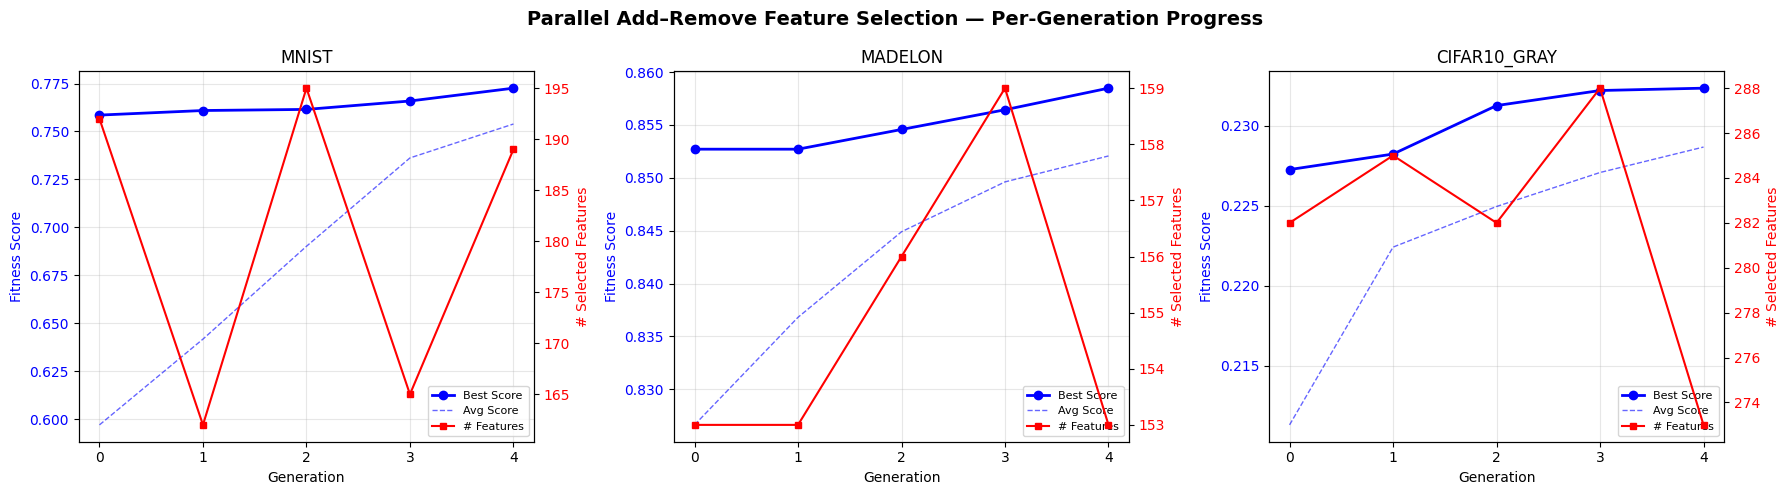

✅ Plot saved as parallel_results.png


In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Parallel Add–Remove Feature Selection — Per-Generation Progress",
             fontsize=14, fontweight='bold')

for ax, (ds_name, result) in zip(axes, all_experiment_results.items()):
    stats       = result["all_stats"]
    gens        = [s["generation"]      for s in stats]
    best_scores = [s["best_score"]      for s in stats]
    avg_scores  = [s["avg_score"]       for s in stats]
    n_features  = [s["best_n_features"] for s in stats]

    ax2 = ax.twinx()

    ax.plot(gens, best_scores, 'b-o', label='Best Score', linewidth=2, markersize=6)
    ax.plot(gens, avg_scores,  'b--', label='Avg Score',  linewidth=1, alpha=0.6)
    ax2.plot(gens, n_features, 'r-s', label='# Features', linewidth=1.5, markersize=5)

    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness Score", color='blue')
    ax2.set_ylabel("# Selected Features", color='red')
    ax.set_title(ds_name.upper())
    ax.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='red')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(gens)

plt.tight_layout()
plt.savefig("parallel_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as parallel_results.png")

In [ ]:
# ============================================================
# MILESTONE 3 — ELITE PROTECTION
# ============================================================

class EliteVault:
    """
    Stores the top-k masks seen across all generations.
    Prevents the best solutions from being lost when operators
    mutate the population in a bad direction.
    """

    def __init__(self, vault_size=5):
        self.vault_size = vault_size
        self._elites = []   # list of (score, mask) sorted descending

    #public API

    def update(self, scored_population):
        """
        Add (score, mask) pairs; keep only the top vault_size unique masks.
        Call this after every merged generation.
        """
        # Combine existing elites with new candidates
        combined = self._elites + list(scored_population)

        # Deduplicate by mask fingerprint, keep highest score per mask
        seen = {}
        for score, mask in combined:
            key = tuple(mask.astype(int))
            if key not in seen or score > seen[key][0]:
                seen[key] = (score, mask)

        # Sort and trim to vault_size
        self._elites = sorted(seen.values(), key=lambda x: x[0], reverse=True)[:self.vault_size]

    def inject(self, population):
        """
        Replace the worst masks in population with vault elites.
        Guarantees the best-ever masks survive into the next generation.
        """
        if not self._elites:
            return population

        pop = list(population)   # shallow copy — masks are np arrays

        # Score the current population so we can evict the worst entries
        # (We keep a stable sort to avoid unnecessary churn)
        n_inject = min(len(self._elites), len(pop))
        # Overwrite the LAST n_inject slots (assumed worst after merge sort)
        for i, (_, elite_mask) in enumerate(self._elites[:n_inject]):
            pop[-(i + 1)] = elite_mask.copy()

        return pop

    def best(self):
        """Return (score, mask) of the overall best mask seen so far."""
        return self._elites[0] if self._elites else (0.0, None)

    def top_masks(self):
        """Return just the elite masks (no scores) as a list."""
        return [mask for _, mask in self._elites]

    def summary(self):
        print(f"   🏆 EliteVault ({len(self._elites)}/{self.vault_size} slots filled)")
        for rank, (score, mask) in enumerate(self._elites, 1):
            n_feat = int(np.sum(mask))
            print(f"      #{rank}: score={score:.6f}  features={n_feat}")


print("✅ EliteVault loaded.")


In [ ]:
# ============================================================
# MILESTONE 3 — EXCHANGE PROTOCOL
# ============================================================

class ExchangeProtocol:
    """
    Defines how the AdditionOperator and RemovalOperator share
    their best findings every few generations to speed convergence.

    Exchange rule:
      - Every `exchange_interval` generations, each operator's
        population receives the top `n_exchange` masks from the
        other operator's population.
      - The donor masks replace the weakest slots in the recipient
        population (bottom of the sorted list).
      - This cross-pollination prevents either operator from
        converging in isolation.
    """

    def __init__(self, fitness_fn, exchange_interval=2, n_exchange=3):
        self.fitness_fn        = fitness_fn
        self.exchange_interval = exchange_interval  # how often to exchange
        self.n_exchange        = n_exchange          # masks to migrate each time
        self.exchange_log      = []                  # history for diagnostics

    def should_exchange(self, generation):
        """Return True if an exchange should happen this generation."""
        return (generation > 0) and (generation % self.exchange_interval == 0)

    def exchange(self, pop_add, pop_rem,
                 X_train, X_test, y_train, y_test, generation):
        """
        Perform one bilateral exchange between the two populations.

        Returns:
            pop_add_updated, pop_rem_updated
        """
        # Score both populations
        scored_add = self._score_population(pop_add, X_train, X_test, y_train, y_test)
        scored_rem = self._score_population(pop_rem, X_train, X_test, y_train, y_test)

        # Top-n from each operator's output
        top_from_add = [mask for _, mask in scored_add[:self.n_exchange]]
        top_from_rem = [mask for _, mask in scored_rem[:self.n_exchange]]

        # Inject the other side's best into the bottom slots
        new_pop_add = self._inject_migrants(pop_add, top_from_rem)
        new_pop_rem = self._inject_migrants(pop_rem, top_from_add)

        self.exchange_log.append({
            "generation"          : generation,
            "best_add_before"     : scored_add[0][0]  if scored_add else 0.0,
            "best_rem_before"     : scored_rem[0][0]  if scored_rem else 0.0,
            "n_migrants_per_side" : self.n_exchange,
        })

        print(f"   🔁 Exchange @ gen {generation}: "
              f"add_best={scored_add[0][0]:.5f}  "
              f"rem_best={scored_rem[0][0]:.5f}  "
              f"migrants={self.n_exchange}")

        return new_pop_add, new_pop_rem

    # -- helpers

    def _score_population(self, population, X_train, X_test, y_train, y_test):
        """Evaluate and sort a population; return [(score, mask), ...] descending."""
        scored = []
        for mask in population:
            score, _, _, _ = self.fitness_fn.evaluate(
                mask, X_train, X_test, y_train, y_test)
            scored.append((score, mask))
        scored.sort(key=lambda x: x[0], reverse=True)
        return scored

    def _inject_migrants(self, population, migrants):
        """Replace the last len(migrants) slots of population with migrant masks."""
        pop = list(population)
        for i, m in enumerate(migrants):
            pop[-(i + 1)] = m.copy()
        return pop


print("✅ ExchangeProtocol loaded.")


In [ ]:
# ============================================================
# MILESTONE 3 — COORDINATED SEARCH RUNNER
# ============================================================

def run_coordinated_search(
    coordinator,
    initial_population,
    X_train, X_test, y_train, y_test,
    fitness_fn,
    n_generations     = 8,
    vault_size        = 5,
    exchange_interval = 2,
    n_exchange        = 3,
    logger            = None,
):
    """
    Full coordinated loop:
      1. Every exchange_interval gens → ExchangeProtocol migrates best masks
         between the two operators' snapshots before the generation runs.
      2. Run one parallel generation via ParallelCoordinator.
      3. Score merged population → update EliteVault.
      4. Inject vault elites back into population (Elite Protection).
    """
    vault    = EliteVault(vault_size=vault_size)
    exchange = ExchangeProtocol(
        fitness_fn        = fitness_fn,
        exchange_interval = exchange_interval,
        n_exchange        = n_exchange,
    )

    population = copy.deepcopy(initial_population)
    all_stats  = []

    print(f"\n{'='*60}")
    print(f" COORDINATED SEARCH — {n_generations} GENERATIONS")
    print(f" Vault size: {vault_size}  |  Exchange every: {exchange_interval} gens")
    print(f"{'='*60}")

    for gen in range(n_generations):

        # Step 1: cross-operator exchange (if due)
        if exchange.should_exchange(gen):
            pop_add_snap = copy.deepcopy(population)
            pop_rem_snap = copy.deepcopy(population)
            pop_add_snap, pop_rem_snap = exchange.exchange(
                pop_add_snap, pop_rem_snap,
                X_train, X_test, y_train, y_test,
                generation=gen
            )
            # Blend exchanged snapshots back: even slots from add, odd from rem
            for i in range(len(population)):
                population[i] = pop_add_snap[i] if i % 2 == 0 else pop_rem_snap[i]

        # Step 2: parallel generation
        population, gen_stats = coordinator.run_generation(
            population, X_train, X_test, y_train, y_test,
            generation=gen, logger=logger
        )

        # Step 3: update vault
        scored = []
        for mask in population:
            score, _, _, _ = fitness_fn.evaluate(
                mask, X_train, X_test, y_train, y_test)
            scored.append((score, mask))
        vault.update(scored)

        # Step 4: inject elites (Elite Protection)
        population = vault.inject(population)

        vault_best_score, _ = vault.best()
        print(f"   🛡️  Elite injected | vault_best={vault_best_score:.6f}")

        all_stats.append(gen_stats)

    print(f"\n🏁 Coordinated search complete!")
    vault.summary()

    return population, all_stats, vault


print("✅ run_coordinated_search() loaded.")


In [ ]:
# ============================================================
# MILESTONE 3 — RUN COORDINATED EXPERIMENTS
# ============================================================

N_GENERATIONS     = 8
POPULATION_SIZE   = 20
VAULT_SIZE        = 5
EXCHANGE_INTERVAL = 2
N_EXCHANGE        = 3

m3_results = {}

for ds_name, data in datasets.items():
    print(f"\n{'#'*60}")
    print(f"# DATASET: {ds_name.upper()}")
    print(f"{'#'*60}")

    X_train = data["X_train"]
    X_test  = data["X_test"]
    y_train = data["y_train"]
    y_test  = data["y_test"]

    evaluator  = NaiveBayesEvaluator()
    fitness_fn = FitnessFunction(evaluator, alpha=0.01)
    logger     = ResultsLogger(ds_name)

    addition_op = AdditionOperator(
        fitness_fn    = fitness_fn,
        bias_computer = bias_computers[ds_name],
        n_additions   = 3, use_bias=True, random_state=42
    )
    removal_op = RemovalOperator(
        fitness_fn        = fitness_fn,
        sparsity_computer = sparsity_computers[ds_name],
        n_removals        = 3, use_bias=True, min_features=5, random_state=42
    )
    coordinator = ParallelCoordinator(
        addition_op     = addition_op,
        removal_op      = removal_op,
        fitness_fn      = fitness_fn,
        population_size = POPULATION_SIZE,
    )

    init_pop = create_initial_population(
        n_features      = data["n_features"],
        population_size = POPULATION_SIZE,
        init_density    = 0.3,
        bias_computer   = bias_computers[ds_name],
        random_state    = 42
    )

    final_pop, all_stats, vault = run_coordinated_search(
        coordinator        = coordinator,
        initial_population = init_pop,
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        fitness_fn         = fitness_fn,
        n_generations      = N_GENERATIONS,
        vault_size         = VAULT_SIZE,
        exchange_interval  = EXCHANGE_INTERVAL,
        n_exchange         = N_EXCHANGE,
        logger             = logger,
    )

    m3_results[ds_name] = {
        "final_pop": final_pop,
        "all_stats": all_stats,
        "vault"    : vault,
        "logger"   : logger,
    }

print("\n\n✅ All Milestone 3 experiments complete!")
